In [3]:
pwd

'C:\\Users\\HP'

In [4]:
import os
print(os.getcwd())

C:\Users\HP


In [5]:
import pandas as pd
import plotly.express as px

# 1. Load your manually downloaded file
# Make sure the name matches your screenshot exactly!
df = pd.read_csv("fashion_boutique_dataset.csv")

# 2. Confirm it loaded by looking at the first 5 rows
print("Success! Data loaded. Here is a preview:")
print(df.head())

# 3. Quick check: What columns do we have?
print("\nYour available columns are:")
print(df.columns)

Success! Data loaded. Here is a preview:
  product_id     category            brand  season size  color  \
0   FB000001    Outerwear             Zara  Spring   XL    Red   
1   FB000002         Tops           Uniqlo  Winter    L   Pink   
2   FB000003  Accessories           Uniqlo  Winter  NaN  Black   
3   FB000004        Shoes           Uniqlo  Spring   XL  Black   
4   FB000005         Tops  Banana Republic  Winter   XL  Black   

   original_price  markdown_percentage  current_price purchase_date  \
0          196.01                  0.0         196.01    2025-07-05   
1          119.64                  0.0         119.64    2025-08-06   
2           33.80                  0.0          33.80    2025-08-06   
3           75.36                  0.0          75.36    2025-07-07   
4          105.02                  0.0         105.02    2025-08-06   

   stock_quantity  customer_rating  is_returned return_reason  
0              37              3.0        False           NaN  
1      

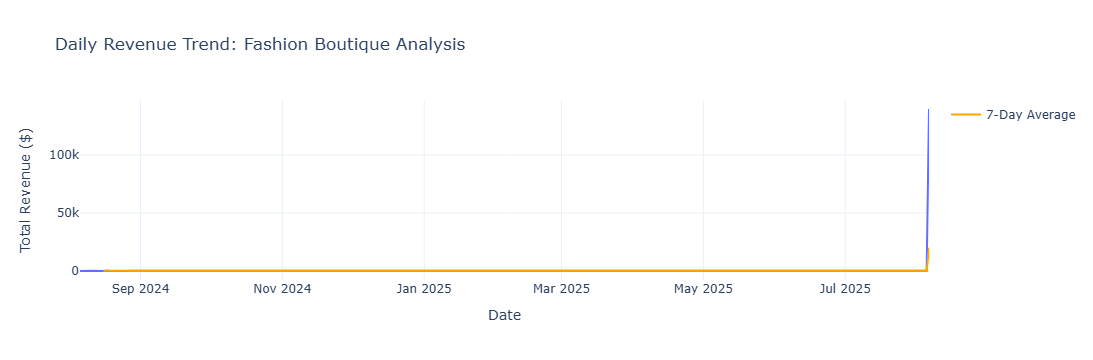

In [6]:
import plotly.express as px

# 1. Prepare the data
# Convert the date column so Python understands the timeline
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

# Group by date to see total daily revenue
daily_revenue = df.groupby('purchase_date')['current_price'].sum().reset_index()

# 2. Create the Interactive Graph
fig = px.line(daily_revenue, x='purchase_date', y='current_price', 
              title='Daily Revenue Trend: Fashion Boutique Analysis',
              labels={'current_price': 'Total Revenue ($)', 'purchase_date': 'Date'},
              template='plotly_white')

# Add a trend line to see the general direction
fig.add_scatter(x=daily_revenue['purchase_date'], 
                y=daily_revenue['current_price'].rolling(window=7).mean(), 
                name='7-Day Average', line=dict(color='orange', width=2))

fig.show()

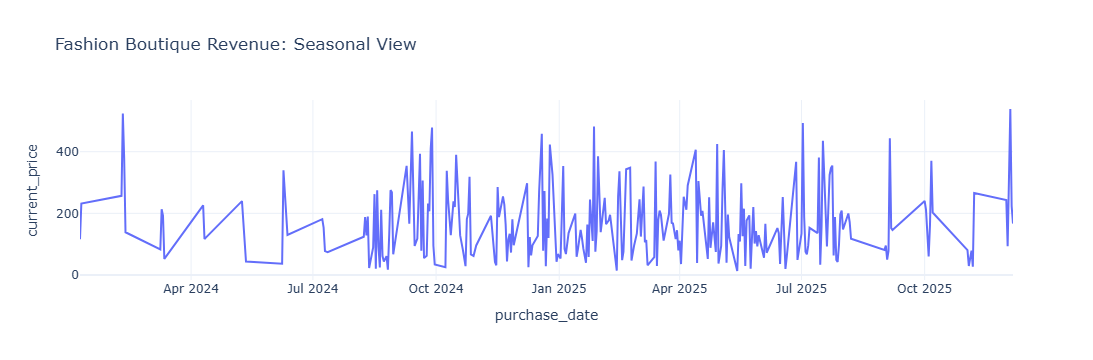

In [8]:
import pandas as pd
import plotly.express as px

# 1. Reload the data
df = pd.read_csv("fashion_boutique_dataset.csv")

# 2. Use 'mixed' format to handle those extra characters
# This will automatically fix the "9" that was causing the crash
df['purchase_date'] = pd.to_datetime(df['purchase_date'], format='mixed', dayfirst=True)

# 3. Group and Clean Outliers
daily_rev = df.groupby('purchase_date')['current_price'].sum().reset_index()

# We'll remove the top 1% of sales just to keep the graph readable
limit = daily_rev['current_price'].quantile(0.99)
daily_rev = daily_rev[daily_rev['current_price'] <= limit]

# 4. Plot the results
fig = px.line(daily_rev, x='purchase_date', y='current_price', 
              title='Fashion Boutique Revenue: Seasonal View',
              template='plotly_white')
fig.show()

Timeline fixed! Total days in dataset: 698
  purchase_date  current_price
0    2024-01-09         115.76
1    2024-01-10         231.98
2    2024-01-11           0.00
3    2024-01-12           0.00
4    2024-01-13           0.00
5    2024-01-14           0.00
6    2024-01-15           0.00
7    2024-01-16           0.00
8    2024-01-17           0.00
9    2024-01-18           0.00


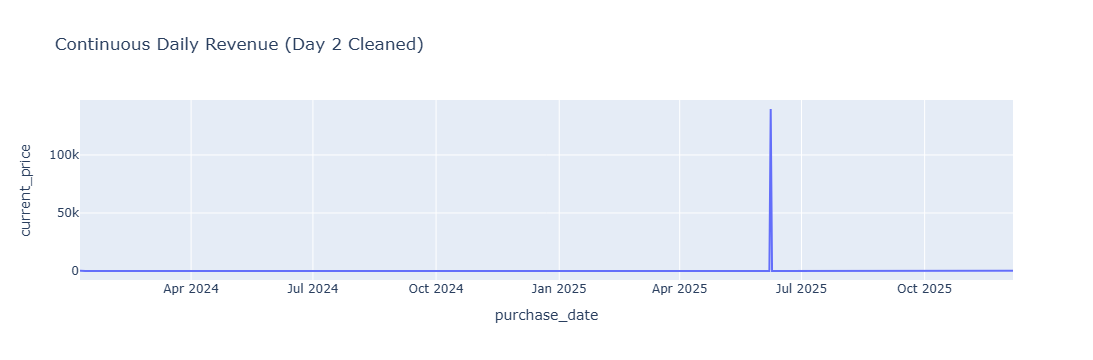

In [1]:
import pandas as pd
import plotly.express as px

# 1. Load the data
df = pd.read_csv("fashion_boutique_dataset.csv")

# 2. Fix the date format (using 'mixed' to prevent the error we saw earlier)
df['purchase_date'] = pd.to_datetime(df['purchase_date'], format='mixed', dayfirst=True)

# 3. Resample: This creates a row for every single day and fills gaps with 0
# This is the "Heartbeat" fix for Day 2
daily_data = df.groupby('purchase_date')['current_price'].sum().resample('D').asfreq().fillna(0).reset_index()

# 4. Success Check
print(f"Timeline fixed! Total days in dataset: {len(daily_data)}")
print(daily_data.head(10))

# 5. Visual Check
fig = px.line(daily_data, x='purchase_date', y='current_price', 
              title='Continuous Daily Revenue (Day 2 Cleaned)')
fig.show()

Cleanup Complete!
Total days in timeline: 698
Normal revenue limit used for clipping: $325.03
  purchase_date  current_price  current_price_cleaned  is_weekend
0    2024-01-09         115.76                 115.76           0
1    2024-01-10         231.98                 231.98           0
2    2024-01-11           0.00                   0.00           0
3    2024-01-12           0.00                   0.00           0
4    2024-01-13           0.00                   0.00           1
5    2024-01-14           0.00                   0.00           1
6    2024-01-15           0.00                   0.00           0
7    2024-01-16           0.00                   0.00           0
8    2024-01-17           0.00                   0.00           0
9    2024-01-18           0.00                   0.00           0


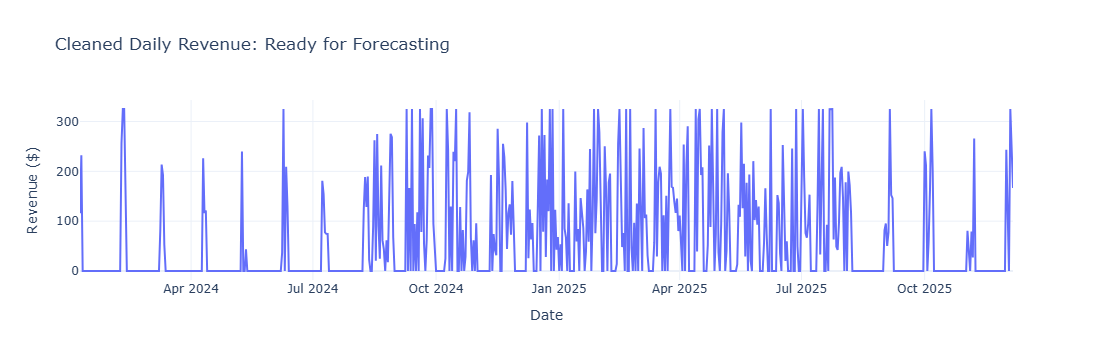

In [2]:
import pandas as pd
import plotly.express as px

# --- STEP 1: LOAD & INITIAL CLEANING ---
# Load your dataset
df = pd.read_csv("fashion_boutique_dataset.csv")

# Standardize the date format to prevent errors
df['purchase_date'] = pd.to_datetime(df['purchase_date'], format='mixed', dayfirst=True)

# Fill missing Metadata (NaNs)
# We use 'Unknown' for sizes and the 'Median' for ratings to stay neutral
df['size'] = df['size'].fillna('Unknown')
df['customer_rating'] = df['customer_rating'].fillna(df['customer_rating'].median())


# --- STEP 2: CREATE THE CONTINUOUS HEARTBEAT (RESAMPLING) ---
# 1. Group by date to get daily revenue totals
daily_data = df.groupby('purchase_date')['current_price'].sum().reset_index()

# 2. Set date as index and resample to Daily ('D') frequency
# .asfreq() adds the missing dates; .fillna(0) marks them as $0 revenue days
daily_data = daily_data.set_index('purchase_date').resample('D').asfreq().fillna(0).reset_index()


# --- STEP 3: TRIM THE NOISE (OUTLIER CLIPPING) ---
# Identify the 95th percentile (the "Normal" ceiling)
limit = daily_data['current_price'].quantile(0.95)

# Clip the spikes so the model focuses on regular shopping patterns
daily_data['current_price_cleaned'] = daily_data['current_price'].clip(upper=limit)


# --- STEP 4: FEATURE ENGINEERING (AI CLUES) ---
# Create a 'Weekend' flag (1 for Sat/Sun, 0 for weekdays)
daily_data['is_weekend'] = daily_data['purchase_date'].dt.dayofweek.isin([5, 6]).astype(int)


# --- STEP 5: VISUALIZE & VERIFY ---
print(f"Cleanup Complete!")
print(f"Total days in timeline: {len(daily_data)}")
print(f"Normal revenue limit used for clipping: ${limit:.2f}")
print(daily_data.head(10))

# Plot the cleaned "Heartbeat"
fig = px.line(daily_data, x='purchase_date', y='current_price_cleaned', 
              title='Cleaned Daily Revenue: Ready for Forecasting',
              labels={'current_price_cleaned': 'Revenue ($)', 'purchase_date': 'Date'},
              template='plotly_white')
fig.show()

16:22:41 - cmdstanpy - INFO - Chain [1] start processing
16:22:42 - cmdstanpy - INFO - Chain [1] done processing


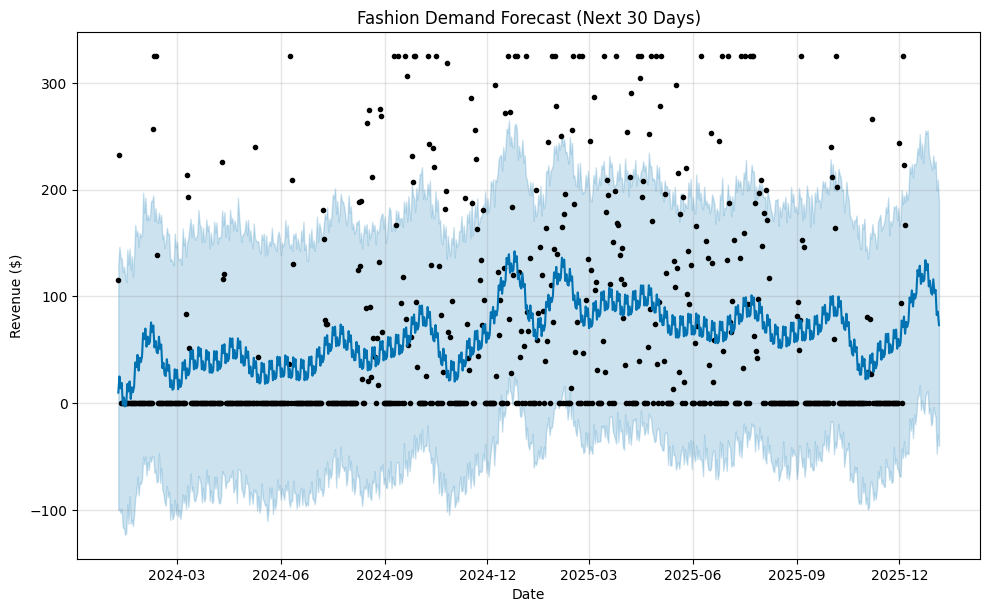

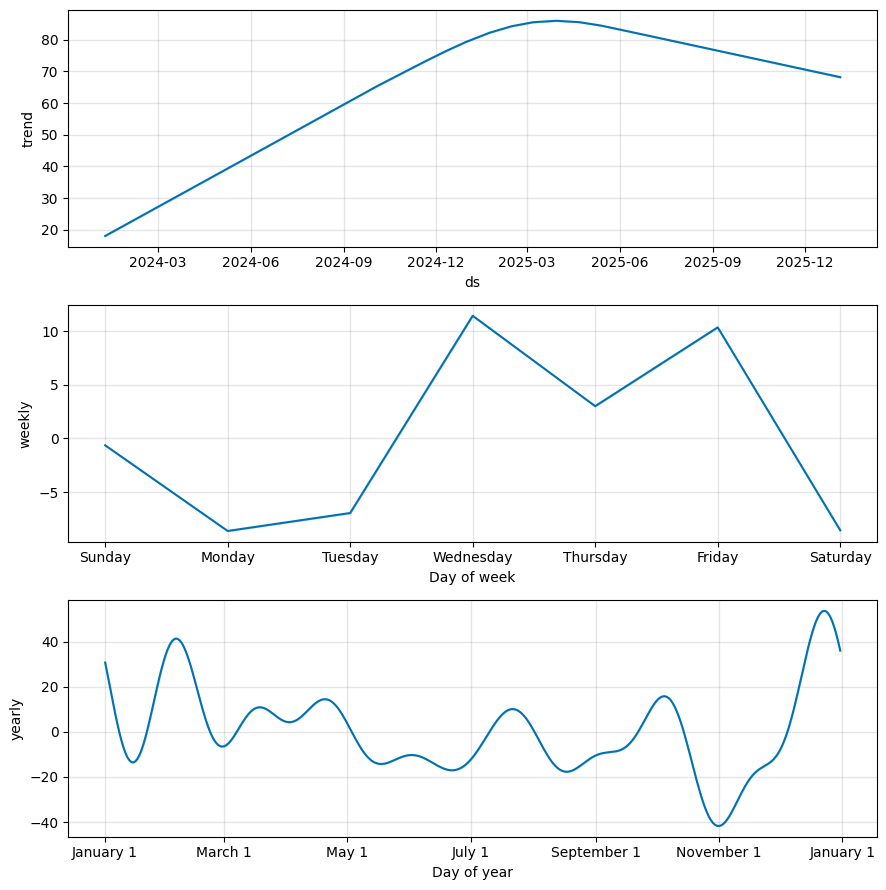

In [3]:
from prophet import Prophet
import matplotlib.pyplot as plt

# 1. Prepare data for the AI (Prophet needs 'ds' for dates and 'y' for values)
df_prophet = daily_data[['purchase_date', 'current_price_cleaned']].rename(
    columns={'purchase_date': 'ds', 'current_price_cleaned': 'y'}
)

# 2. Initialize the Model with "Boutique Logic"
# We enable yearly and weekly patterns so it knows about seasons and weekends
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(df_prophet)

# 3. Create a 30-day "Future" timeline
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# 4. Plot #1: The Main Forecast Chart
# This shows the historical dots and the blue prediction line
fig1 = model.plot(forecast)
plt.title("Fashion Demand Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.show()

# 5. Plot #2: The "Secrets" of the Boutique
# This shows exactly how much weekends vs weekdays affect your sales
fig2 = model.plot_components(forecast)
plt.show()


In [7]:
# 1. Increase the prediction range to 60 days to reach March 1st
future = model.make_future_dataframe(periods=100)
forecast = model.predict(future)

# 2. Search specifically for the March 1st date
march_1st_pred = forecast[forecast['ds'] == '2026-03-01']

# 3. Print the results for your checkpoint
if not march_1st_pred.empty:
    expected = march_1st_pred['yhat'].values[0]
    low = march_1st_pred['yhat_lower'].values[0]
    high = march_1st_pred['yhat_upper'].values[0]
    print(f"--- CHECKPOINT RESULT: MARCH 1st ---")
    print(f"Predicted Revenue: ${expected:.2f}")
    print(f"Confidence Range: ${low:.2f} to ${high:.2f}")
else:
    print("Still not reaching March 1st. The current forecast ends on:")
    print(forecast['ds'].max())

--- CHECKPOINT RESULT: MARCH 1st ---
Predicted Revenue: $57.34
Confidence Range: $-61.81 to $179.57


In [8]:
from prophet.diagnostics import performance_metrics
from prophet.diagnostics import cross_validation

# 1. Run a 'back-test' to see how the model would have performed in the past
df_cv = cross_validation(model, initial='365 days', period='30 days', horizon='30 days')

# 2. Calculate the performance metrics
df_p = performance_metrics(df_cv)

# 3. View the accuracy (MAPE)
print("--- MODEL ACCURACY REPORT ---")
print(df_p[['horizon', 'rmse', 'mae', 'mape']].head())


Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|                                               | 0/11 [00:00<?, ?it/s]17:27:36 - cmdstanpy - INFO - Chain [1] start processing
17:27:36 - cmdstanpy - INFO - Chain [1] done processing
  9%|███▌                                   | 1/11 [00:00<00:06,  1.66it/s]17:27:37 - cmdstanpy - INFO - Chain [1] start processing
17:27:37 - cmdstanpy - INFO - Chain [1] done processing
 18%|███████                                | 2/11 [00:01<00:05,  1.68it/s]17:27:37 - cmdstanpy - INFO - Chain [1] start processing
17:27:37 - cmdstanpy - INFO - Chain [1] done processing
 27%|██████████▋                            | 3/11 [00:01<00:04,  1.72it/s]17:27:38 - cmdstanpy - INFO - Chain [1] start processing
17:27:38 - cmdstanpy - INFO - Chain [1] done processing
 36%|██████████████▏                        | 4/11 [00:02<00:04,  1.64it/s]17:27:39 - cmdstanpy - INFO - Chain [1] start processing
17:27:39 - c

--- MODEL ACCURACY REPORT ---


KeyError: "['mape'] not in index"

In [10]:
# 1. View the actual columns the model created
print("--- ACCURACY METRICS FOUND ---")
print(df_p.columns)

# 2. Display the head of the metrics table safely
print("\n--- MODEL PERFORMANCE SUMMARY ---")
print(df_p.head())

--- ACCURACY METRICS FOUND ---
Index(['horizon', 'mse', 'rmse', 'mae', 'mdape', 'smape', 'coverage'], dtype='str')

--- MODEL PERFORMANCE SUMMARY ---
  horizon           mse        rmse         mae     mdape     smape  coverage
0  3 days  17633.234580  132.790190  120.166807       inf  1.875308  0.515152
1  4 days  16221.622644  127.364134  113.713209       inf  1.705328  0.545455
2  5 days  20133.022879  141.890884  127.190624  7.773111  1.529929  0.454545
3  6 days  17515.356977  132.345597  117.552055  2.106115  1.368067  0.484848
4  7 days  20978.955317  144.841138  130.886898  1.635252  1.374933  0.424242
